<strong><h1>TRANSFORMAÇÃO POR COMPONENTES PRINCIPAIS</h1></strong>

Este notebook mostra o processo de criação dos fatores utilizados como variáveis preditoras no treino e teste do modelo de Florestas Aleatórias (Random Forest) e Regressão Linear Multinível

In [71]:
import pandas as pd

from utilitarios.visualizacao \
    import DiagnosticoMulticolinearidade, EstatisticasDescritivas, VisualizadorExploratorio

from utilitarios.pca import ExtratorPCATematico

In [72]:
df_unificado_filtrado = pd.read_parquet(r'dados_brutos/base_de_dados_filtrada.parquet')


In [73]:
variaveis = [
    "POP_TOTAL_RESIDENTE", "POP_URBANA_RESIDENTE", "ENERGIA_ELETRICA", "GINI_2010","THEIL_2010",
    "ENS_FUND_25_ANOS_OU_MAIS", "ENS_MEDIO_25_ANOS_OU_MAIS", "COLETA_LIXO", "POP_AGUA_ENCANADA",
    "REDE_ESGOTO","AGUA-ESGOTAMENTO_INADEQUADOS","POP_ECON_ATIVA","PROP_POBRES",
    "PROP_VULNERAVEIS_POBREZA","RENDA_PERCAPITA_5_MAIS_POBRE",
    "PROP_EXTREM_POBRES","TAXA_DESOCUP_18_MAIS","ANALFABETISMO_15_ANOS",
]

diag_multicolinearidade = DiagnosticoMulticolinearidade(
    df=df_unificado_filtrado, 
    features=variaveis
    )

,Feature,VIF
0,POP_TOTAL_RESIDENTE,6962.09
1,POP_URBANA_RESIDENTE,5377.97
2,POP_ECON_ATIVA,698.03
3,PROP_POBRES,268.89
4,PROP_VULNERAVEIS_POBREZA,164.29
5,PROP_EXTREM_POBRES,64.16
6,THEIL_2010,57.36
7,GINI_2010,54.08
8,ENS_FUND_25_ANOS_OU_MAIS,50.05
9,ENS_MEDIO_25_ANOS_OU_MAIS,41.95


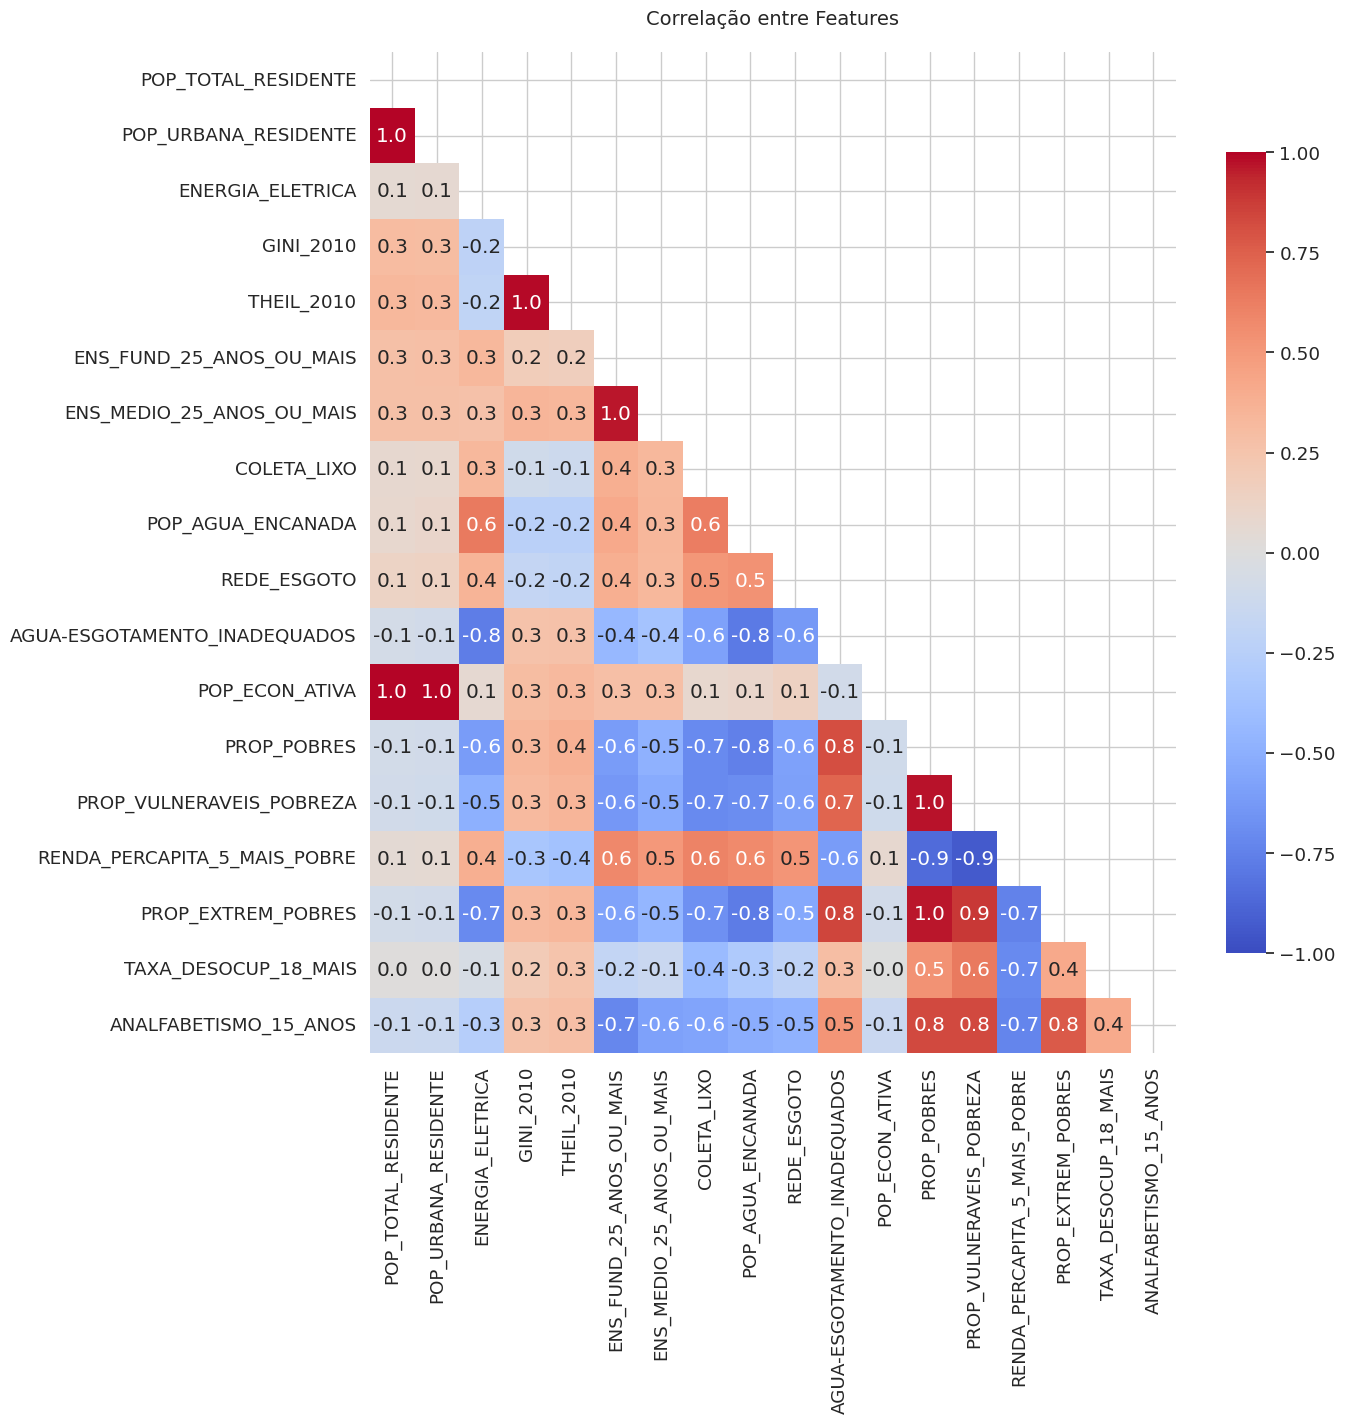

In [74]:
diag_multicolinearidade.plotar_matriz_correlacao(decimais=1)
diag_multicolinearidade.calcular_vif()

<strong><h2>Definição temática das variáveis</h2></strong>

Na célula seguinte, as variáveis originais são transformadas em fatores ortogonais a partir da análise de componentes principais. Não se trata de uma transformação global, mas de uma transformação temática, de modo que as variáveis do mesmo tema são agrupadas em um unico fator:

In [75]:
df_unificado_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 282 entries, 11 to 5595
Data columns (total 45 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   COD                                   282 non-null    int64  
 1   REGIAO                                282 non-null    object 
 2   UF                                    282 non-null    object 
 3   MUNICIPIO                             282 non-null    object 
 4   POP_TOTAL_RESIDENTE                   282 non-null    float32
 5   POP_RURAL_RESIDENTE                   282 non-null    float32
 6   POP_URBANA_RESIDENTE                  282 non-null    float32
 7   POP_HOMEM_RESIDENTE                   282 non-null    float32
 8   POP_MULHER_RESIDENTE                  282 non-null    float32
 9   POP_COR_BRANCA                        282 non-null    float32
 10  POP_COR_NEGRA                         282 non-null    float32
 11  IDHM_2010             

In [76]:
temas = {
    'POPULACAO': [
        'POP_TOTAL_RESIDENTE', "POP_URBANA_RESIDENTE"
    ],
    'EDUCACAO': [
        'ANALFABETISMO_15_ANOS','ENS_FUND_25_ANOS_OU_MAIS', 'ENS_MEDIO_25_ANOS_OU_MAIS'
    ],
    'INFRAESTRUTURA': [
        'COLETA_LIXO','ENERGIA_ELETRICA','AGUA-ESGOTAMENTO_INADEQUADOS','POP_AGUA_ENCANADA','REDE_ESGOTO'
    ],
    'POBREZA_DESIGUALDADE': [
        'PROP_POBRES','PROP_VULNERAVEIS_POBREZA',"PROP_EXTREM_POBRES",'THEIL_2010', 'GINI_2010', "RENDA_PERCAPITA_5_MAIS_POBRE"
    ],

    'EMPREGO': [
        'TAXA_DESOCUP_18_MAIS','POP_ECON_ATIVA'
    ]
}

extrator = ExtratorPCATematico(
    dicionario_temas=temas, 
    temas_inverter_sinal=['INFRAESTRUTURA', 'EMPREGO']
    )

In [77]:
df_pca_completo = extrator.fit_transform(df_unificado_filtrado)
extrator.exibir_relatorio()

      RELATÓRIO DE EXTRAÇÃO DE FATORES (PCA)      

[FATOR: POPULACAO]
Variância Explicada: 99.99%
Composição (Loadings):
POP_TOTAL_RESIDENTE     0.707107
POP_URBANA_RESIDENTE    0.707107

[FATOR: EDUCACAO]
Variância Explicada: 84.10%
Composição (Loadings):
ANALFABETISMO_15_ANOS       -0.518347
ENS_FUND_25_ANOS_OU_MAIS     0.619530
ENS_MEDIO_25_ANOS_OU_MAIS    0.589490

[FATOR: INFRAESTRUTURA]
Variância Explicada: 66.86%
Composição (Loadings):
COLETA_LIXO                     0.405663
ENERGIA_ELETRICA                0.420555
AGUA-ESGOTAMENTO_INADEQUADOS   -0.510735
POP_AGUA_ENCANADA               0.487429
REDE_ESGOTO                     0.400166

[FATOR: POBREZA_DESIGUALDADE]
Variância Explicada: 68.73%
Composição (Loadings):
PROP_POBRES                     0.469716
PROP_VULNERAVEIS_POBREZA        0.465310
PROP_EXTREM_POBRES              0.444375
THEIL_2010                      0.298732
GINI_2010                       0.285607
RENDA_PERCAPITA_5_MAIS_POBRE   -0.441103

[FATOR: EMPREGO]
V

In [78]:
colunas_finais = ['TAXA_VIOLENCIA'] + [f'FATOR_{t}' for t in temas.keys()]
df_final_modelagem = df_pca_completo[colunas_finais]

In [79]:
df_final_modelagem

,TAXA_VIOLENCIA,FATOR_POPULACAO,FATOR_EDUCACAO,FATOR_INFRAESTRUTURA,FATOR_POBREZA_DESIGUALDADE,FATOR_EMPREGO
11,3.35,-0.431122,-1.079682,-1.119399,0.257393,0.466237
16,46.30,0.080458,0.627689,-2.752599,0.264671,0.602110
66,28.24,-0.070077,-0.130609,-1.727298,1.979358,-0.298648
111,46.09,2.447704,1.777184,-1.002320,1.835574,0.327186
119,9.61,-0.473446,-1.137024,-10.353118,6.794020,-0.388835
...,...,...,...,...,...,...
5483,81.05,-0.332241,-1.570495,-0.980261,0.492036,-0.485690
5546,50.67,-0.330002,-0.752463,0.539168,-0.642229,0.519899
5581,8.46,-0.445507,-1.742905,0.270395,-1.127337,0.300541
5589,76.09,-0.393126,1.187604,-0.089478,-0.386461,0.122382


In [80]:
diag_multicolinearidade_fatores = DiagnosticoMulticolinearidade(
    df=df_final_modelagem,
     features=df_final_modelagem.columns.to_list())

,Feature,VIF
0,FATOR_POBREZA_DESIGUALDADE,4.59
1,FATOR_EMPREGO,3.53
2,FATOR_POPULACAO,3.19
3,FATOR_INFRAESTRUTURA,2.96
4,FATOR_EDUCACAO,1.73
5,TAXA_VIOLENCIA,1.27


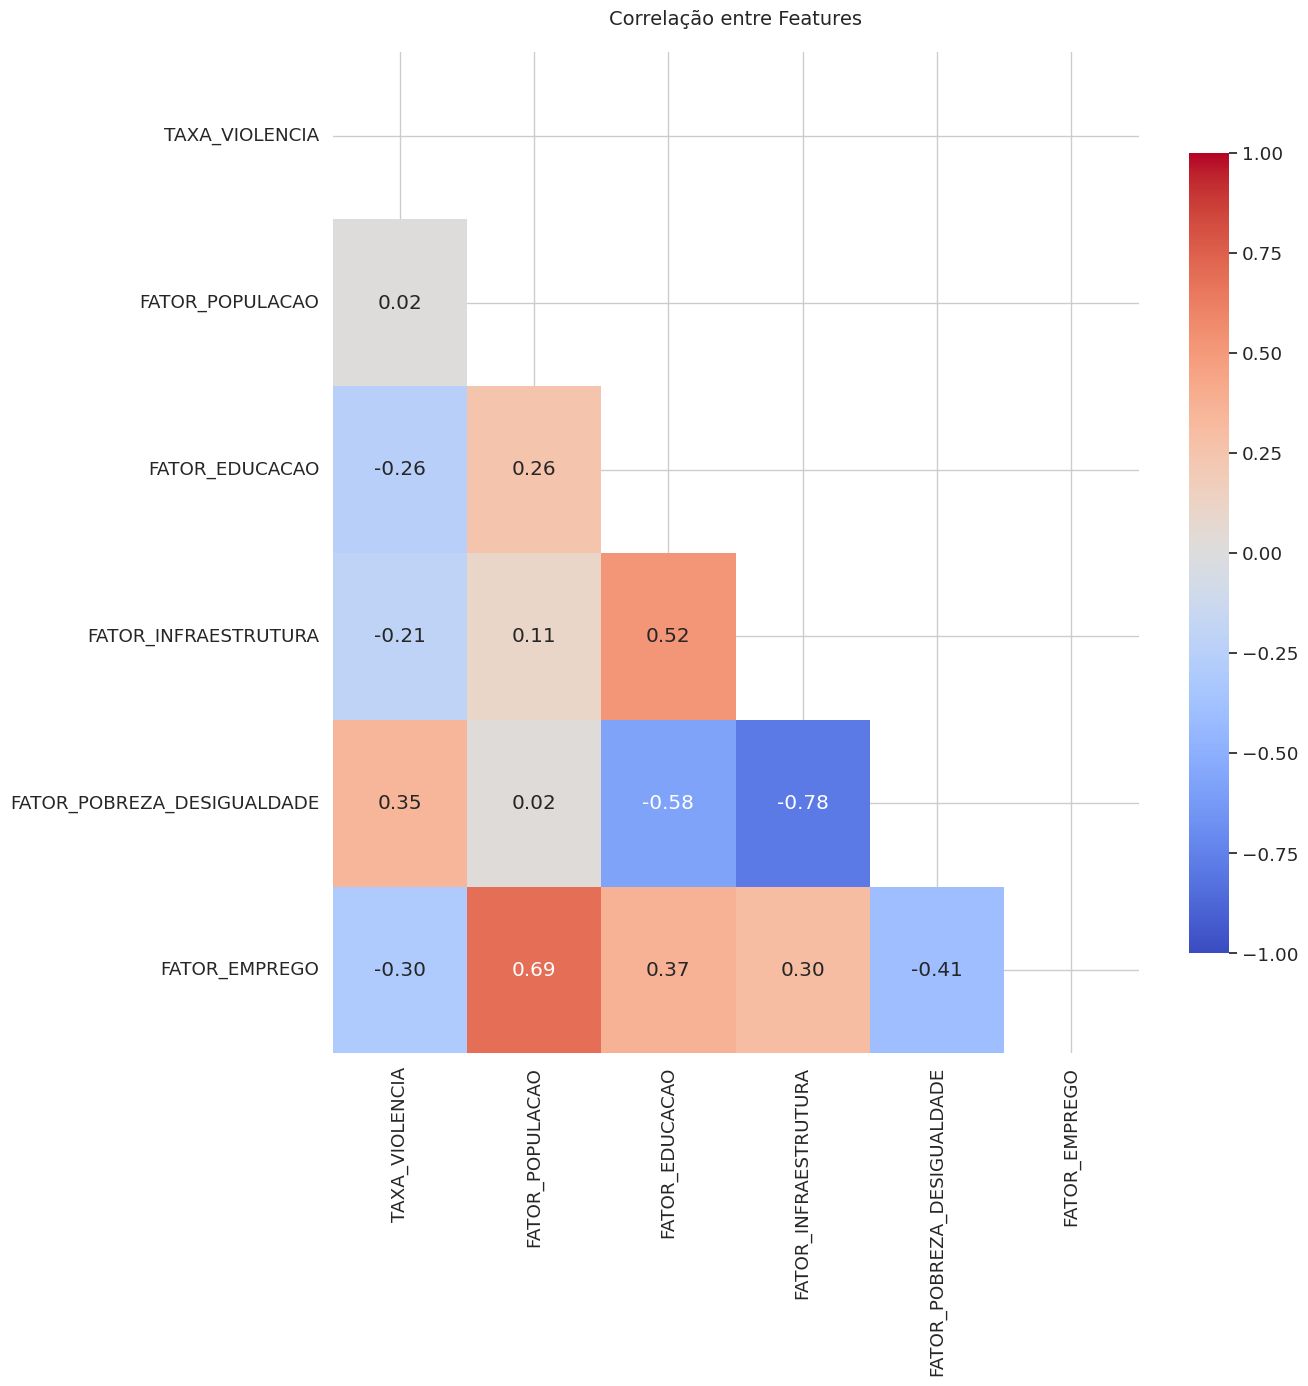

In [81]:
diag_multicolinearidade_fatores.plotar_matriz_correlacao(2)
diag_multicolinearidade_fatores.calcular_vif()

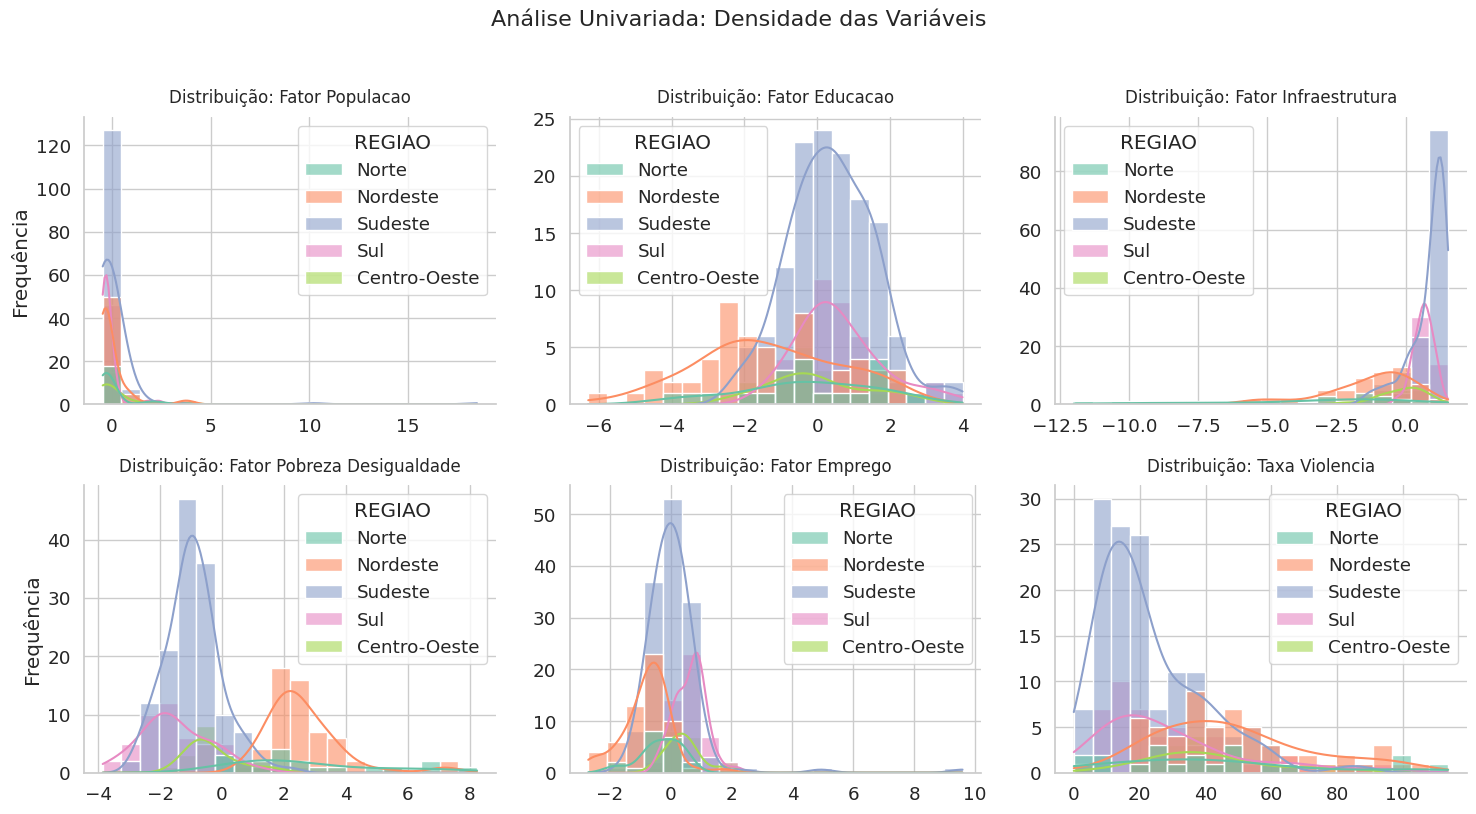

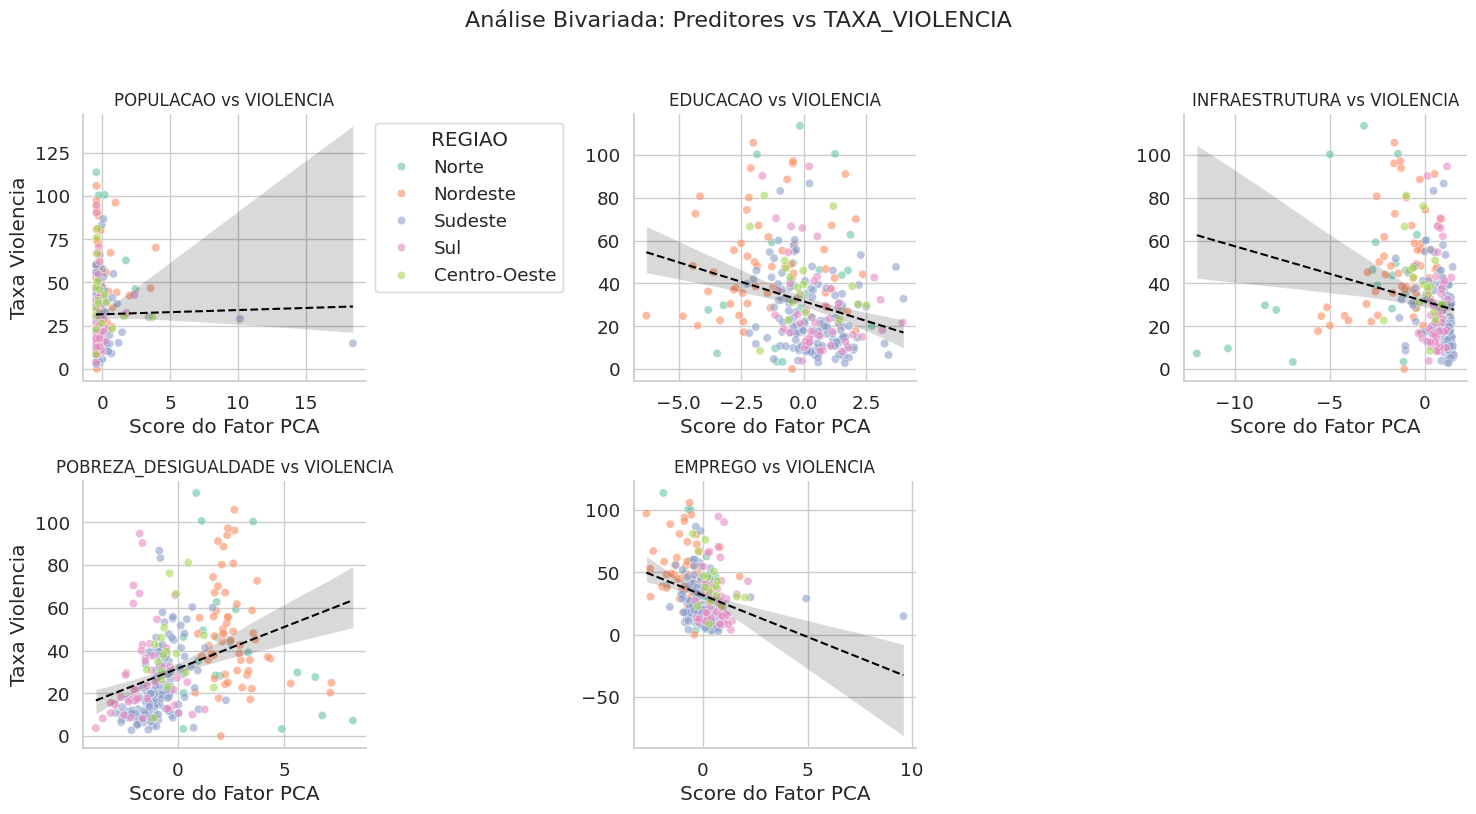

In [82]:
variavel_alvo = 'TAXA_VIOLENCIA'
fatores_extraidos = [col for col in df_final_modelagem.columns if col != variavel_alvo]
variaveis_distribuicao = fatores_extraidos + [variavel_alvo]

# Instancia o visualizador com o DF processado pela nossa classe PCA
viz = VisualizadorExploratorio(df_pca_completo)

# Gera os plots de forma completamente agnóstica à quantidade de variáveis
viz.plotar_distribuicoes(variaveis=variaveis_distribuicao, hue='REGIAO', max_colunas=3)
viz.plotar_relacionamentos(preditores=fatores_extraidos, alvo=variavel_alvo, hue='REGIAO', max_colunas=3)

### **Visualização dos fatores por unidade federativa**


In [83]:
df_pca_completo.groupby('UF')[['TAXA_VIOLENCIA','FATOR_EMPREGO']].agg({
    'FATOR_EMPREGO': 'mean',
    'TAXA_VIOLENCIA':'mean'
        }
    ).round(2)

,FATOR_EMPREGO,TAXA_VIOLENCIA
UF,,
AC,-0.30,28.24
AL,-0.43,84.32
AM,-0.03,27.85
AP,-1.30,41.44
BA,-0.93,66.18
CE,-0.16,35.08
DF,2.02,29.78
ES,-0.05,56.89
GO,0.33,47.73


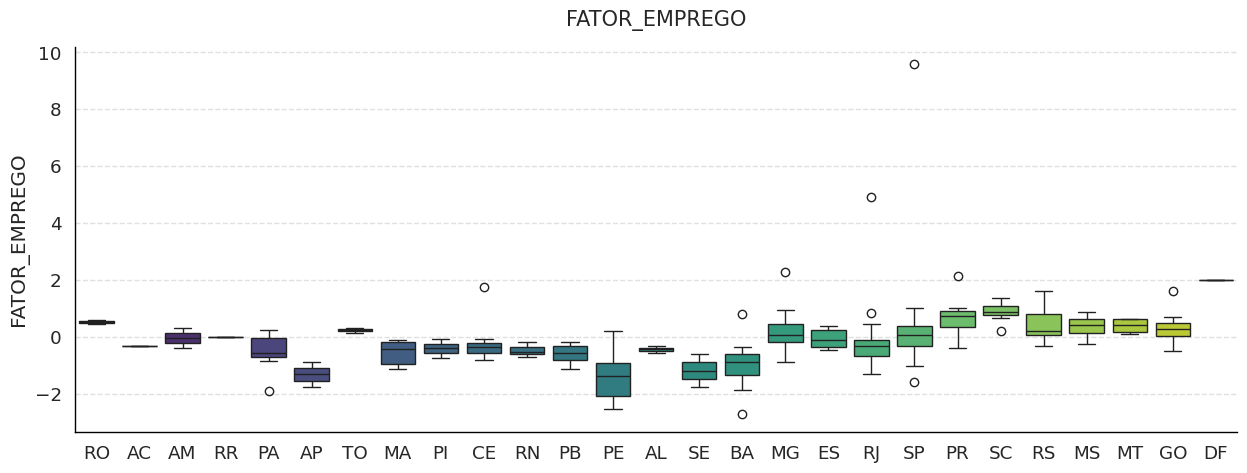

In [55]:
ed = EstatisticasDescritivas(df_pca_completo)

ed.plot_box_uf(
    "FATOR_EMPREGO", 
    "FATOR_EMPREGO", 
    x='UF',
    y='FATOR_EMPREGO',
    hue='UF')

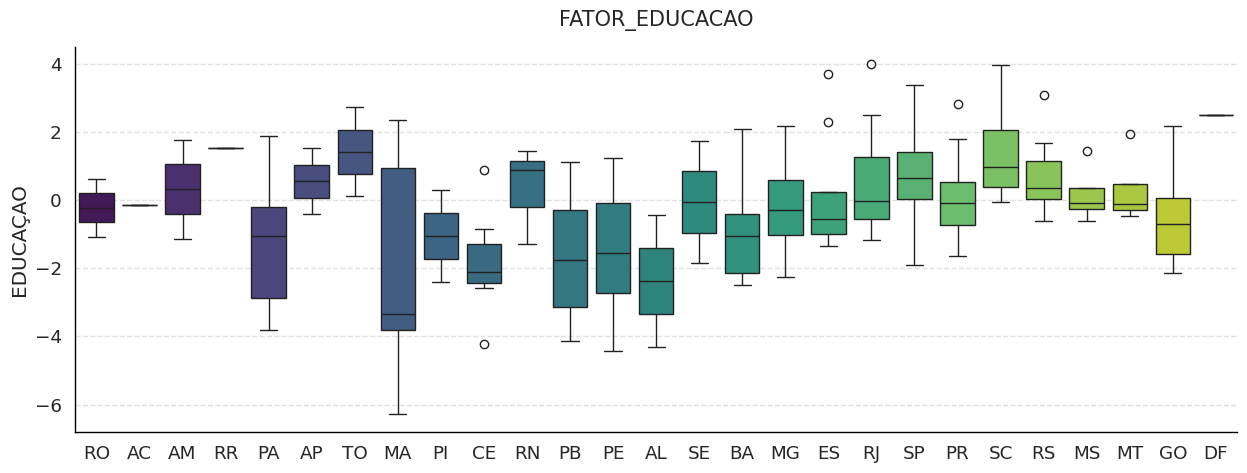

In [56]:
ed.plot_box_uf(
    "FATOR_EDUCACAO", 
    "EDUCAÇAO", 
    x='UF',
    y='FATOR_EDUCACAO',
    hue='UF')

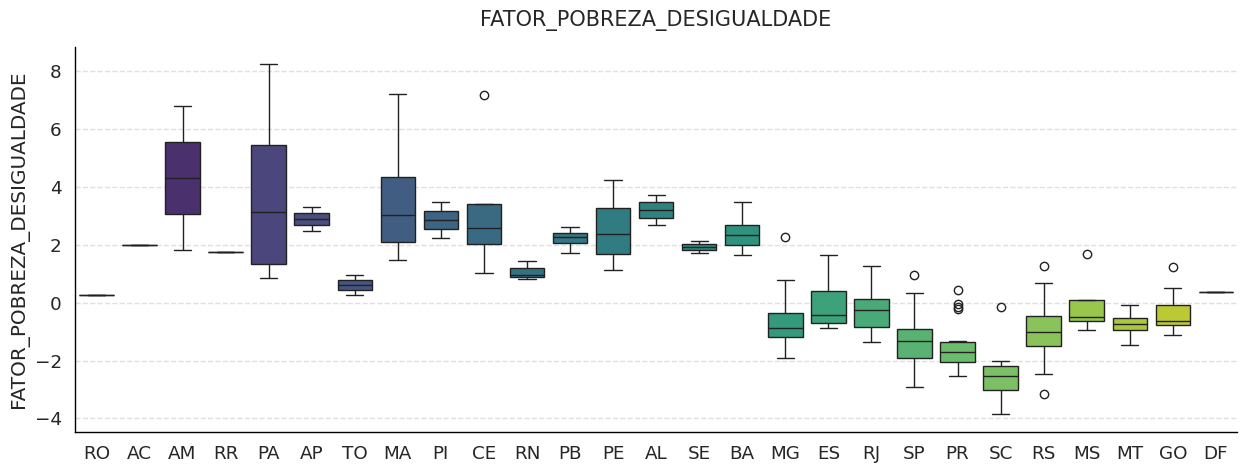

In [57]:
ed.plot_box_uf(
    "FATOR_POBREZA_DESIGUALDADE", 
    "FATOR_POBREZA_DESIGUALDADE", 
    x='UF',
    y='FATOR_POBREZA_DESIGUALDADE',
    hue='UF')

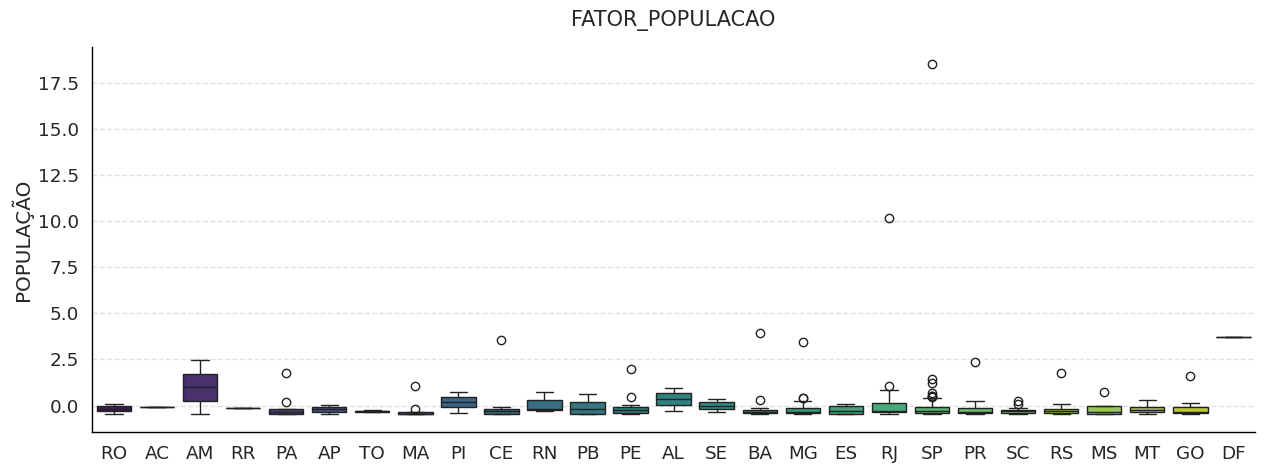

In [18]:
ed.plot_box_uf(
    "FATOR_POPULACAO", 
    "POPULAÇÃO",
    x='UF',
    y='FATOR_POPULACAO',
    hue='UF'
    )

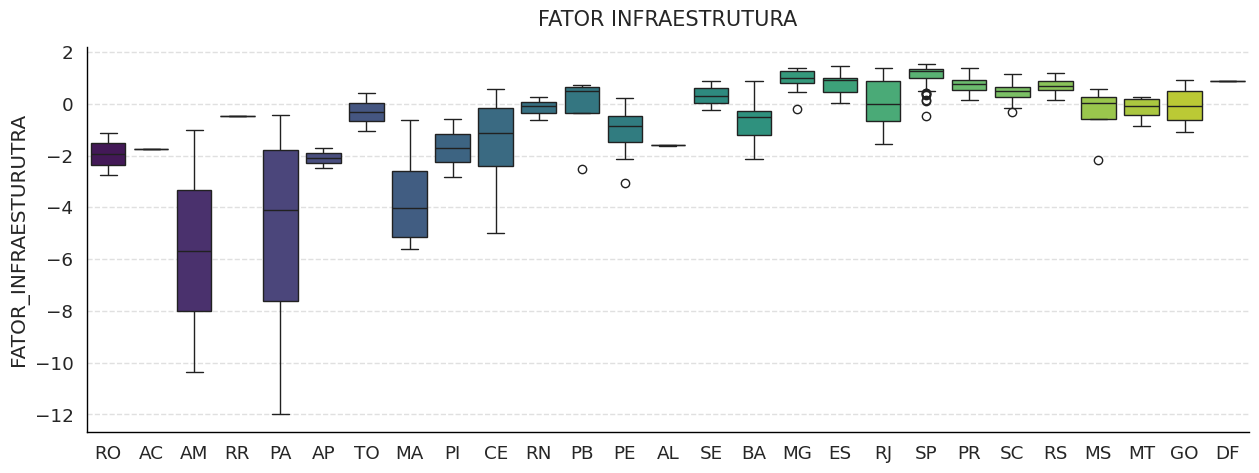

In [22]:
ed.plot_box_uf(
    "FATOR INFRAESTRUTURA", 
    "FATOR_INFRAESTURUTRA", 
    x='UF',
    y='FATOR_INFRAESTRUTURA',
    hue='UF'
    )

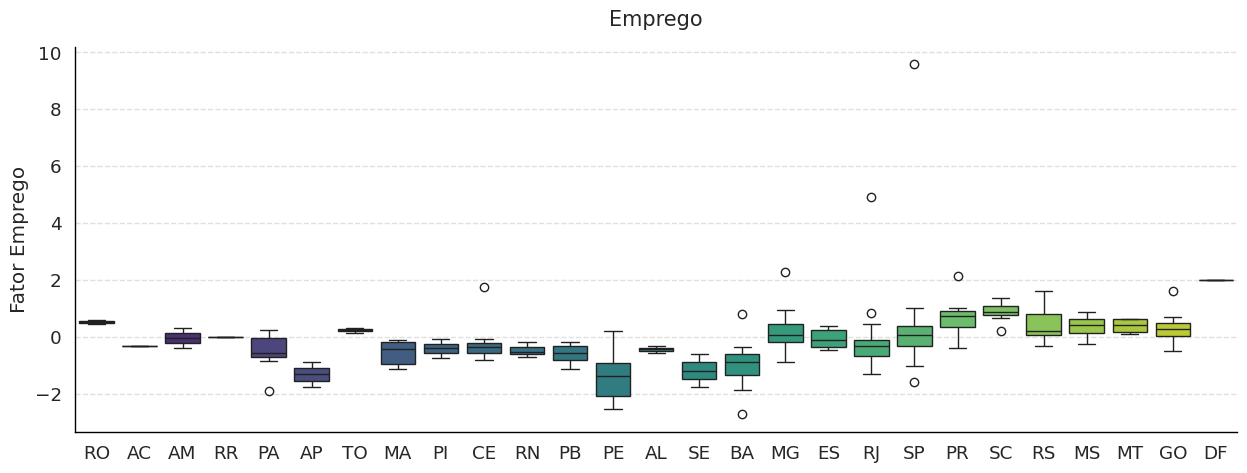

In [88]:
ed.plot_box_uf(
    "Emprego", 
    "Fator Emprego", 
    x='UF',
    y='FATOR_EMPREGO',
    hue='UF'
    )